In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [5]:
df = pd.read_csv("/content/height-weight.csv")

In [6]:
df.head(5)

,Weight,Height
0,45,120
1,58,135
2,48,123
3,60,145
4,70,160


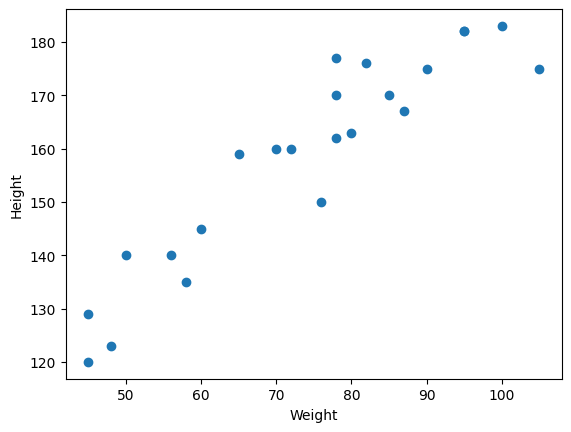

In [7]:
plt.scatter(df['Weight'],df['Height'])
plt.xlabel("Weight")
plt.ylabel("Height")
plt.show()

In [8]:
df.corr()

,Weight,Height
Weight,1.000000,0.931142
Height,0.931142,1.000000


In [9]:
X = df[['Weight']]
y = df['Height']

In [10]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42)

In [11]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
scaler.fit(X_train)
X_train = scaler.transform(X_train)
X_test = scaler.transform(X_test)

In [12]:
X_train

array([[ 1.73689094],
       [-0.92026952],
       [ 1.4542143 ],
       [ 0.21043706],
       [-1.48562281],
       [ 1.17153765],
       [-1.6552288 ],
       [-0.80719886],
       [-0.24184557],
       [ 0.0973664 ],
       [-1.37255215],
       [-1.03334018],
       [-0.12877492],
       [ 0.88886101],
       [ 0.43657837],
       [ 0.60618436],
       [ 0.71925502],
       [ 0.32350772]])

In [13]:
X_train.shape

(18, 1)

In [14]:
from sklearn.linear_model import LinearRegression

In [15]:
regression = LinearRegression()

In [16]:
regression.fit(X_train,y_train)

LinearRegression()

In [17]:
print("Co efficient/slope of the data: ")
print(regression.coef_)

Co efficient/slope of the data: 
[17.03440872]


In [18]:
print("Intercept of the data: ")
print(regression.intercept_)

Intercept of the data: 
157.5


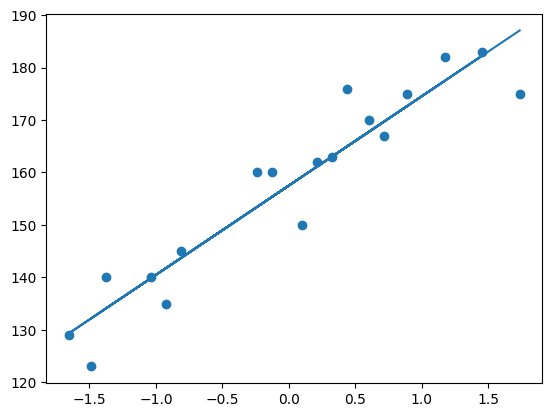

In [19]:
plt.scatter(X_train, y_train)
plt.plot(X_train, regression.predict(X_train))

In [20]:
#prediction of the test data
y_predict = regression.predict(X_test)

In [21]:
print(y_predict)

[161.08467086 161.08467086 129.3041561  177.45645118 148.56507414]


In [22]:
from sklearn.metrics import mean_absolute_error,mean_squared_error
mae = mean_absolute_error(y_test, y_predict)
mse = mean_squared_error(y_test,y_predict)
rmse = np.sqrt(mse)
print(mae)
print(mse)
print(rmse)

9.822657814519232
109.77592599051664
10.477400726827081


In [23]:

from sklearn.metrics import r2_score

In [24]:
score = r2_score(y_test, y_predict)
print(score)

0.776986986042344


In [27]:
adj_r2_score = 1- ( ((1 - score)* (len(y_test)) / (len(y_test) - 1 - (X_test.shape[1]) )))

In [28]:
print(adj_r2_score)

0.6283116434039067


In [32]:
new_val = [[28]]
scaled_new_val = scaler.transform(new_val)
regression.predict(scaled_new_val)

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


array([112.93237578])